# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [ ]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [ ]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [ ]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

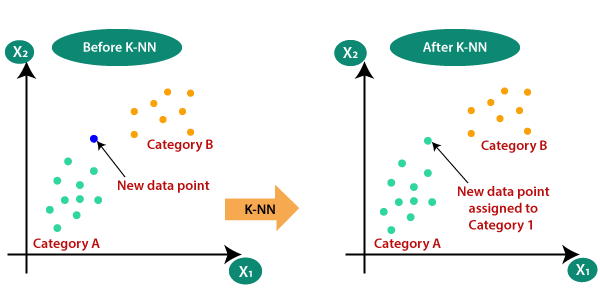

In [ ]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [ ]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [ ]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [ ]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [ ]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


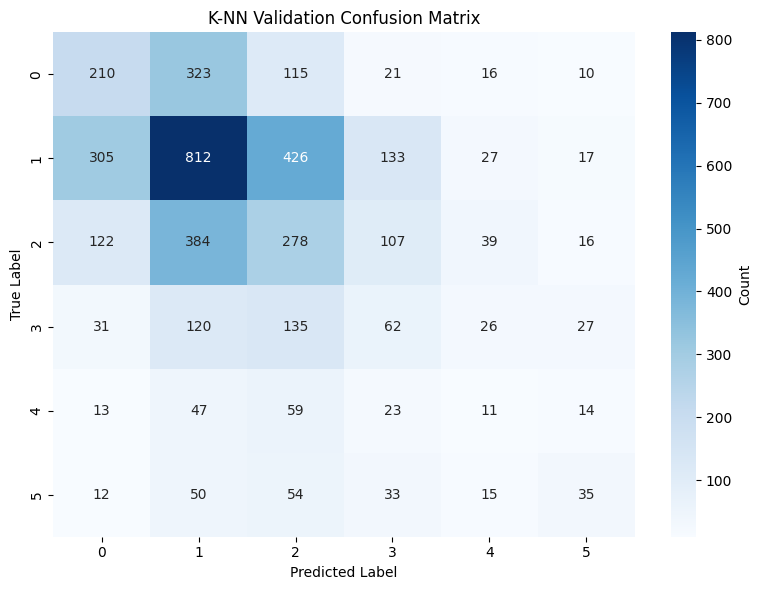

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [ ]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [ ]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [ ]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

1) How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
Answer: If we increase the percentage of the validation set, more data is kept aside for testing the model and less data is available for training. Because the model gets less data to learn from, its accuracy may decrease. However, the validation accuracy can be more reliable because it is tested on a larger number of samples.
If we reduce the validation set percentage, more data is given to the model for training, so it may learn better and give better accuracy. But the validation set becomes smaller, so the accuracy may change more depending on which data is selected for validation.
So, we need to maintain a good balance between the training and validation data. Usually, keeping around 20–30% of the data for validation works well.



2) How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
Answer: The size of the training and validation sets plays an important role in predicting how well the model will perform on the test set. If we have a larger training set, the model gets more data to learn from and can usually make better predictions. However, if the validation set is too small, its accuracy may not give us a clear idea of how the model will perform on unseen data. On the other hand, having a larger validation set gives us a more reliable estimate of the model’s performance, but leaves less data for training. Therefore, we need to maintain a proper balance between the training and validation sets so that the validation accuracy gives us a good idea of the expected test accuracy.


3) What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?
Answer: I think keeping around **20–30% of the data for validation** is a good choice. This gives the model enough data to learn properly while also keeping a reasonable amount of data aside to check its performance. If we keep too much data for validation, the model will have less data to train on. If we keep too little, the validation accuracy may not be reliable. So, using around 20–30% gives a good balance between training the model and getting a reliable estimate of how it may perform on the test data.


In [4]:
# Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

data = fetch_california_housing()

X = data.data
y = data.target.astype(int)

alltraindata, testdata, alltrainlabel, testlabel = train_test_split(
    X, y, test_size=0.25, random_state=42
)

knn1 = KNeighborsClassifier(n_neighbors=1)

knn1.fit(alltraindata, alltrainlabel)

pred1 = knn1.predict(testdata)

accuracy1 = accuracy_score(testlabel, pred1)

print("1-NN Accuracy:", accuracy1 * 100, "%")

knn3 = KNeighborsClassifier(n_neighbors=3)

knn3.fit(alltraindata, alltrainlabel)

pred3 = knn3.predict(testdata)

accuracy3 = accuracy_score(testlabel, pred3)

print("3-NN Accuracy:", accuracy3 * 100, "%")

print("\nComparison:")
print("1-NN Accuracy:", accuracy1 * 100, "%")
print("3-NN Accuracy:", accuracy3 * 100, "%")

if accuracy1 > accuracy3:
    print("1-NN has higher accuracy.")
elif accuracy3 > accuracy1:
    print("3-NN has higher accuracy.")
else:
    print("Both have the same accuracy.")

1-NN Accuracy: 35.077519379844965 %
3-NN Accuracy: 35.46511627906977 %

Comparison:
1-NN Accuracy: 35.077519379844965 %
3-NN Accuracy: 35.46511627906977 %
3-NN has higher accuracy.


In this exercise, I implemented both 1-NN and 3-NN and compared their accuracies on the test dataset. In 1-NN, the model looks at the closest data point to make a prediction, whereas in 3-NN, it looks at the three closest data points and chooses the class that occurs the most.After comparing the results, I found that the accuracies of 1-NN and 3-NN are quite similar, although there can be a small difference between them. 3-NN considers more nearby data points, so its prediction is not based on just one point. This experiment helped me understand how changing the number of neighbours can affect the accuracy of the model.


## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [ ]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [ ]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 33.58463539517022 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

1) Does averaging the validation accuracy across multiple splits give more consistent results?
Answer: Yes, averaging the validation accuracy across multiple splits usually gives more consistent results. If we use only one split, the accuracy may be high or low depending on which data is selected for training and validation. By trying different splits and taking the average, these small changes are reduced. This gives us a more reliable idea of how well the model is actually performing. In simple words, using multiple splits and taking the average makes the accuracy more stable and trustworthy.


2) Does it give more accurate estimate of test accuracy?
Answer: Yes, averaging the validation accuracy from different splits usually gives us a **better estimate of the test accuracy**. When we use only one split, the result can depend a lot on which data happens to be selected for training and validation. By trying multiple splits and taking the average, we get a result that is less affected by these random changes.
So, it gives us a more realistic idea of how the model might perform on new, unseen data.



3) What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
Answer: The number of iterations also affects how reliable our estimate is. If we use only a few iterations, the average accuracy can change a lot depending on the particular splits chosen. When we increase the number of iterations, we use more different splits and the average becomes more stable.
So, yes, a higher number of iterations generally gives a better and more reliable estimate, but after a certain point, increasing the iterations may not make a big difference.


4) Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?
Answer: No, increasing the number of iterations cannot completely solve the problem of having a very small training or validation dataset. More iterations can make the average accuracy more stable, but if the training set is too small, the model does not have enough data to learn properly. Similarly, if the validation set is very small, the accuracy can change a lot with even a few different predictions. So, increasing iterations helps to some extent, but it cannot replace having a reasonably sized training and validation set.


Effect of Number of Splits
---------------------------
Splits: 1
1-NN Accuracy: 33.850129198966414 %
3-NN Accuracy: 33.82428940568475 %

Splits: 2
1-NN Accuracy: 34.14728682170542 %
3-NN Accuracy: 33.86304909560723 %

Splits: 5
1-NN Accuracy: 33.5452196382429 %
3-NN Accuracy: 33.66925064599483 %

Splits: 10
1-NN Accuracy: 33.36175710594315 %
3-NN Accuracy: 33.5452196382429 %

Splits: 20
1-NN Accuracy: 33.75452196382429 %
3-NN Accuracy: 33.46124031007752 %

Splits: 50
1-NN Accuracy: 33.79741602067183 %
3-NN Accuracy: 33.565891472868216 %



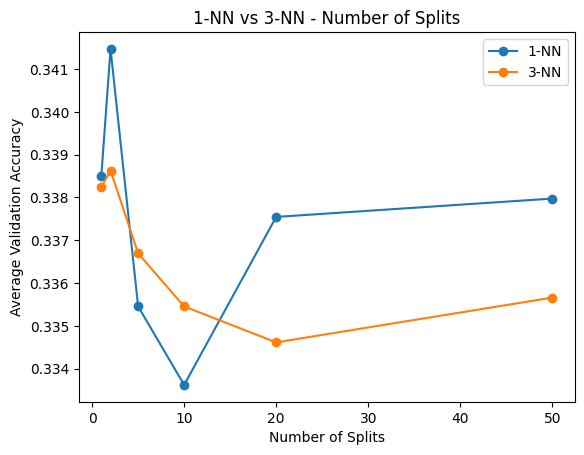

Effect of Split Size
--------------------
Split Size: 0.1
1-NN Accuracy: 33.33333333333333 %
3-NN Accuracy: 33.850129198966414 %

Split Size: 0.2
1-NN Accuracy: 32.81653746770026 %
3-NN Accuracy: 33.68863049095607 %

Split Size: 0.25
1-NN Accuracy: 32.27390180878553 %
3-NN Accuracy: 33.1266149870801 %

Split Size: 0.3
1-NN Accuracy: 32.084409991386735 %
3-NN Accuracy: 33.20413436692506 %

Split Size: 0.4
1-NN Accuracy: 32.25129198966408 %
3-NN Accuracy: 32.99418604651162 %

Split Size: 0.5
1-NN Accuracy: 32.093023255813954 %
3-NN Accuracy: 32.55813953488372 %



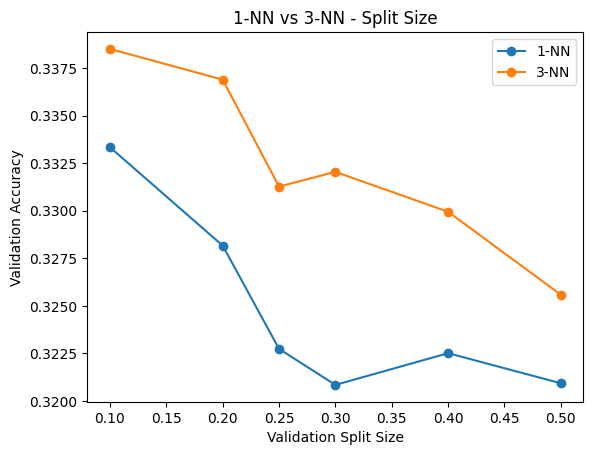

In [6]:
#Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

number_of_splits = [1, 2, 5, 10, 20, 50]

accuracy_1nn = []
accuracy_3nn = []

for n in number_of_splits:
    acc1 = []
    acc3 = []

    for i in range(n):

        X_train, X_val, y_train, y_val = train_test_split(
            alltraindata,
            alltrainlabel,
            test_size=0.25,
            random_state=i
        )

        knn1 = KNeighborsClassifier(n_neighbors=1)
        knn1.fit(X_train, y_train)
        pred1 = knn1.predict(X_val)
        acc1.append(accuracy_score(y_val, pred1))

        knn3 = KNeighborsClassifier(n_neighbors=3)
        knn3.fit(X_train, y_train)
        pred3 = knn3.predict(X_val)
        acc3.append(accuracy_score(y_val, pred3))

    accuracy_1nn.append(sum(acc1) / n)
    accuracy_3nn.append(sum(acc3) / n)


print("Effect of Number of Splits")
print("---------------------------")

for i in range(len(number_of_splits)):
    print("Splits:", number_of_splits[i])
    print("1-NN Accuracy:", accuracy_1nn[i] * 100, "%")
    print("3-NN Accuracy:", accuracy_3nn[i] * 100, "%")
    print()

plt.plot(number_of_splits, accuracy_1nn, marker='o', label='1-NN')
plt.plot(number_of_splits, accuracy_3nn, marker='o', label='3-NN')

plt.xlabel("Number of Splits")
plt.ylabel("Average Validation Accuracy")
plt.title("1-NN vs 3-NN - Number of Splits")
plt.legend()
plt.show()

split_sizes = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5]

accuracy_1nn_size = []
accuracy_3nn_size = []

for size in split_sizes:

    X_train, X_val, y_train, y_val = train_test_split(
        alltraindata,
        alltrainlabel,
        test_size=size,
        random_state=42
    )

    knn1 = KNeighborsClassifier(n_neighbors=1)
    knn1.fit(X_train, y_train)
    pred1 = knn1.predict(X_val)
    accuracy_1nn_size.append(accuracy_score(y_val, pred1))

    knn3 = KNeighborsClassifier(n_neighbors=3)
    knn3.fit(X_train, y_train)
    pred3 = knn3.predict(X_val)
    accuracy_3nn_size.append(accuracy_score(y_val, pred3))


print("Effect of Split Size")
print("--------------------")

for i in range(len(split_sizes)):
    print("Split Size:", split_sizes[i])
    print("1-NN Accuracy:", accuracy_1nn_size[i] * 100, "%")
    print("3-NN Accuracy:", accuracy_3nn_size[i] * 100, "%")
    print()

plt.plot(split_sizes, accuracy_1nn_size, marker='o', label='1-NN')
plt.plot(split_sizes, accuracy_3nn_size, marker='o', label='3-NN')

plt.xlabel("Validation Split Size")
plt.ylabel("Validation Accuracy")
plt.title("1-NN vs 3-NN - Split Size")
plt.legend()
plt.show()

From the results, we can see that the accuracy of both 1-NN and 3-NN changes a little when we change the validation split size. When the validation set is very small, the accuracy can change more because it is calculated using only a small number of data points. As we increase the validation size, the result becomes a little more stable, but at the same time, there is less data available for training.The accuracy of 1-NN and 3-NN is quite close in our results, although one may perform slightly better than the other for some split sizes. Overall, this experiment shows that the choice of split size can affect the accuracy, so we should choose a reasonable split that gives enough data for both training and validation.
